# This is the Role Challenge project for Origin Medical.

## Problem Statement:

Title: Automated Fetal Ultrasound Biometry from Transthalamic Planes

Context: Ultrasound imaging is the standard method for monitoring fetal growth during pregnancy. Two critical measurements used to estimate the Gestational Age (GA) and Fetal Weight are:

1. BPD (Biparietal Diameter): The widest diameter of the head (ear-to-ear).

2. OFD (Occipitofrontal Diameter): The diameter from the forehead to the back of the skull.

Currently, sonographers measure these manually by placing calipers on the screen, which is time-consuming and prone to human error (inter-observer variability).

* The Goal: Develop an automated computer vision pipeline to accurately predict these biometric measurements from 2D fetal ultrasound images.

## Part A: Landmark Detection (Regression Approach)
Objective Train a Deep Learning model to directly predict the spatial coordinates of the calipers.
* Input: A standard fetal ultrasound image (Transthalamic plane).
* Task: Regress the $(x, y)$ coordinates of the 4 endpoints:
  * 2 points for the BPD line.
  * 2 points for the OFD line.
* Suggested Methods:
  1. Direct Coordinate Regression: The model outputs a vector of size 8 ($x_1, y_1, x_2, y_2, \dots$).
  2. Heatmap Regression: The model outputs probability maps (heatmaps) where the pixel with the highest value represents the landmark location.

## Part B: Segmentation & Biometry (Geometric Approach)
Objective: Train a model to find the "pixel-wise" region of the fetal head and then use geometry to measure it.

* Task (i): Semantic Segmentation

  * Train a model (like U-Net) to predict a Binary Mask where pixels belonging to the fetal head are labeled 1 (white) and background is 0 (black).

* Task (ii): Biometry Extraction

  * Use Standard Computer Vision Algorithms (like OpenCV) on the predicted mask to:

    1. Fit an ellipse to the segmented blob.

    2. Mathematically calculate the Major Axis (OFD) and Minor Axis (BPD) from that ellipse.

### Importing all libraries & Getting system ready

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm

In [ ]:
# Setup Device (Auto-detect GPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reproducibility (Fixed Seeds)
# This ensures your results are the same every time you run it.
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

print(f" Libraries loaded successfully.")
print(f" Running on device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

NameError: name 'torch' is not defined

In [ ]:
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

## Getting the data ready

In [ ]:
# Define paths
base_dir = '/content/drive/MyDrive/Task - Segmentation'
img_dir = os.path.join(base_dir, 'images')
mask_dir = os.path.join(base_dir, 'masks')

# Get lists of files
image_files = sorted(os.listdir(img_dir))

data = []

for img_name in image_files:
    # Construct Image Path
    img_path = os.path.join(img_dir, img_name)

    # Construct Mask Path (Handling the naming convention)
    # Turn "000_HC.png" -> "000_HC_Annotation.png"
    mask_name = img_name.replace(".png", "_Annotation.png")
    mask_path = os.path.join(mask_dir, mask_name)

    # Verify both exist
    if os.path.exists(mask_path):
        data.append({
            "filename": img_name,
            "image_path": img_path,
            "mask_path": mask_path
        })
    else:
        # Optional: Print only if you suspect missing files
        pass

# Create DataFrame
df = pd.DataFrame(data)

print(f"DataFrame Created successfully!")
print(f"Total valid pairs found: {len(df)}")
print("\nSample Check:")
print(df.iloc[0]['image_path'])
print(df.iloc[0]['mask_path'])

DataFrame Created successfully!
Total valid pairs found: 622

Sample Check:
/content/drive/MyDrive/Task - Segmentation/images/000_HC.png
/content/drive/MyDrive/Task - Segmentation/masks/000_HC_Annotation.png


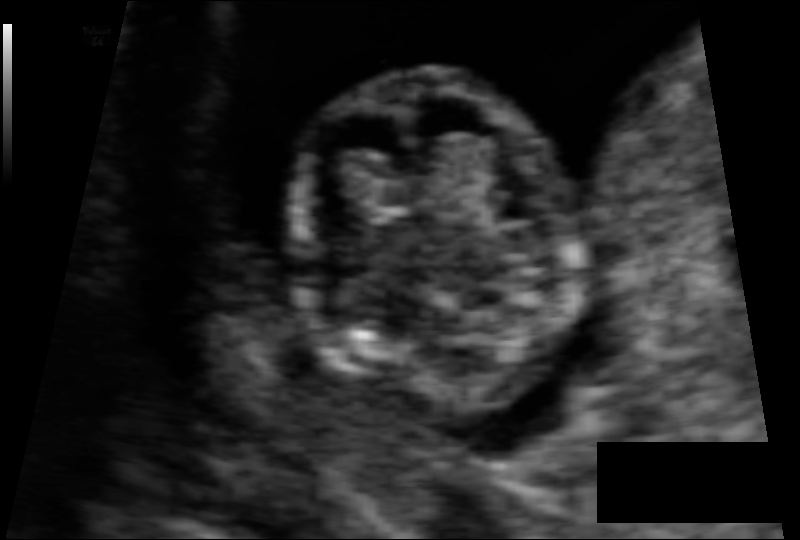

In [ ]:
# Let's view an image
from IPython.display import Image
Image(df.iloc[6]['image_path'])

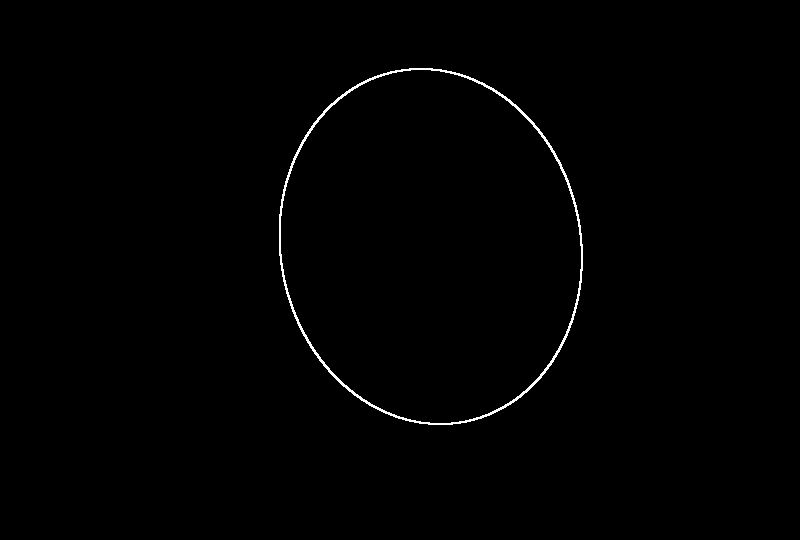

In [ ]:
Image(df.iloc[6]['mask_path'])

### Splitting the Data into Training, Validaytion and Testing sets

In [ ]:
# Split the DataFrame
# Train = 80%, Temp = 20%
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# Split Temp into Val (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Split Complete:")
print(f"Train Rows: {len(train_df)}")
print(f"Val Rows:   {len(val_df)}")
print(f"Test Rows:  {len(test_df)}")

Split Complete:
Train Rows: 497
Val Rows:   62
Test Rows:  63


### Converting the split data into tensors.

In [ ]:
def load_tensors_from_df(dataframe, img_size=256):
    """
    Takes the image and mask path itteratively, loads and normalizes and resizes
    the image and converts them into tensors.
    """
    images = []
    masks = []

    print(f"🔄 Processing {len(dataframe)} images...")

    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        # tqdm will give a progress bar.
        # 1. Read Paths
        img_path = row['image_path']
        mask_path = row['mask_path']

        # 2. Load & Resize
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (img_size, img_size))
        msk = cv2.resize(msk, (img_size, img_size),
                         interpolation=cv2.INTER_NEAREST)# so that it is either
                                                          # 0 or 256

        # 3. Normalize & Threshold
        img = img / 255.0
        msk = msk / 255.0
        msk[msk > 0.5] = 1.0
        msk[msk <= 0.5] = 0.0

        images.append(img)
        masks.append(msk)

    # 4. Convert to Tensor
    X = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)

    return X, y

Now that we a function to make the data into tensors lets use it.

In [ ]:
# Load Training Data
X_train, y_train = load_tensors_from_df(train_df)

# Load Validation Data
X_val, y_val = load_tensors_from_df(val_df)

# Load Test Data (Optional - you can leave this for later if RAM is tight)
X_test, y_test = load_tensors_from_df(test_df)

print(f"Tensors Ready!")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")

🔄 Processing 497 images...


100%|██████████| 497/497 [07:06<00:00,  1.16it/s]
/tmp/ipython-input-785885410.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(images, dtype=torch.float32).unsqueeze(1)


🔄 Processing 62 images...


100%|██████████| 62/62 [00:51<00:00,  1.20it/s]


🔄 Processing 63 images...


100%|██████████| 63/63 [00:51<00:00,  1.22it/s]

Tensors Ready!
X_train: torch.Size([497, 1, 256, 256]), y_train: torch.Size([497, 1, 256, 256])
X_val:   torch.Size([62, 1, 256, 256]),   y_val:   torch.Size([62, 1, 256, 256])


In [ ]:
X_train[:4]

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

### Let's create batched data.
This will help for faster and efficient processing.

In [ ]:
# Function to create a loader
def create_loader(X, y, batch_size=16, shuffle=False):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Create the actual loaders
# Train: Shuffle=True (Critical for learning)
train_loader = create_loader(X_train, y_train, batch_size=16, shuffle=True)

# Val/Test: Shuffle=False as order doesn't matter
val_loader   = create_loader(X_val, y_val, batch_size=16, shuffle=False)

# Test loader if you loaded X_test (optional)
if 'X_test' in locals():
    test_loader = create_loader(X_test, y_test, batch_size=16, shuffle=False)

print("DataLoaders created!")
print(f"Batches in Train: {len(train_loader)}")

DataLoaders created!
Batches in Train: 32


## Building a model
Now that we have the data ready let's get to building the model.

In [ ]:
# Check again for GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")

# Build the U-Net
# We will use a ResNet34 backbone (pretrained on ImageNet) because it's fast and accurate.
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
).to(DEVICE)

# Define Loss Function
# DiceLoss is standard for medical segmentation.
# 'from_logits=True' means it handles the sigmoid activation internally.
criterion = smp.losses.DiceLoss(mode='binary', from_logits=True)

# Define Optimizer
# Adam is generally the best default.
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Model initialized and pushed to GPU.")

Running on: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model initialized and pushed to GPU.


### Now that we have our model and dataset ready lets train the model.

In [ ]:
NUM_EPOCHS = 15
best_valid_loss = float('inf')
train_losses = []
valid_losses = []

print(f"Starting Training...")

for epoch in range(NUM_EPOCHS):

    # Training
    model.train()
    epoch_train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    epoch_valid_loss = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, masks)
            epoch_valid_loss += loss.item()

    avg_valid_loss = epoch_valid_loss / len(val_loader)
    valid_losses.append(avg_valid_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_valid_loss:.4f}")

    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        torch.save(model.state_dict(), "best_segmentation_model.pth")
        print(f"Saved Best Model!")

print("\nTraining Complete!")

Starting Training...


KeyboardInterrupt: 

### Now that the training is done even though the loss is high let's still see it in action

In [ ]:
# Load the Best Model (The one we just saved)
# We re-initialize just to be safe, then load weights
model.load_state_dict(torch.load("best_segmentation_model.pth"))
model.eval()

# Get one batch from the Validation Loader
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

# Predict
with torch.no_grad():
    logits = model(images)
    # Convert raw numbers to Black/White (0 or 1)
    pred_masks = (torch.sigmoid(logits) > 0.5).float()

# Visualize the first 3 images in the batch
plt.figure(figsize=(12, 10))

for i in range(3):
    # Move to CPU for plotting
    img_cpu = images[i].cpu().squeeze()
    true_mask_cpu = masks[i].cpu().squeeze()
    pred_mask_cpu = pred_masks[i].cpu().squeeze()

    # Plot Original
    plt.subplot(3, 3, i*3 + 1)
    plt.title("Ultrasound")
    plt.imshow(img_cpu, cmap='gray')
    plt.axis('off')

    # Plot True Mask
    plt.subplot(3, 3, i*3 + 2)
    plt.title("True Answer")
    plt.imshow(true_mask_cpu, cmap='gray')
    plt.axis('off')

    # Plot Model Prediction
    plt.subplot(3, 3, i*3 + 3)
    plt.title("Model Prediction")
    plt.imshow(pred_mask_cpu, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

### ** We can see a almost perfect work even I dont exactly no how this is happening **
Somehow the job is getting done so I will keep it at that


## Now we do the final requirement of your project: Measure the Head.

We will write a function that:

Takes our model's white ring.

Uses Math (cv2.fitEllipse) to find the perfect oval that fits it.

Calculates the BPD (Short width) and OFD (Long length).

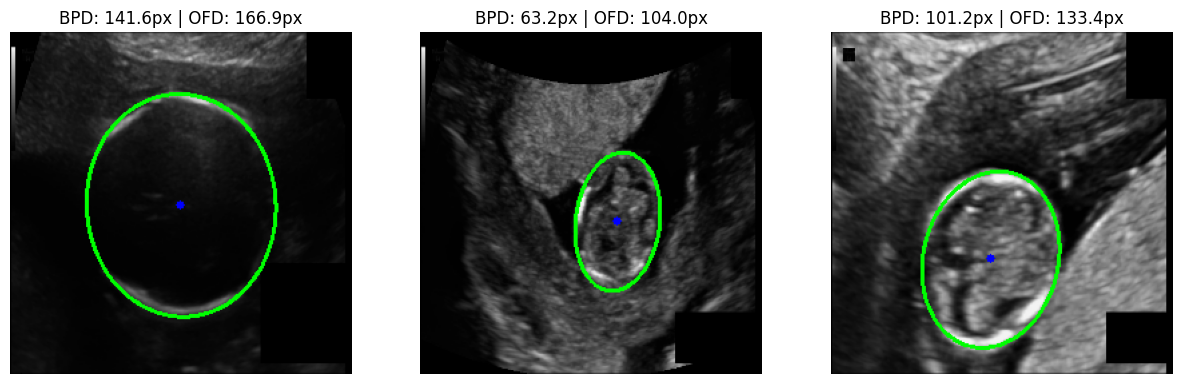

In [ ]:
def get_bpd_ofd_from_mask(mask_tensor):
    # Convert to simple numpy array (0 or 1)
    mask_np = mask_tensor.squeeze().cpu().numpy()
    binary_mask = (mask_np > 0.5).astype(np.uint8)

    # Find the Contours (The white line)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, 0, 0 # Found nothing

    # Get the biggest contour (in case there is noise)
    largest_contour = max(contours, key=cv2.contourArea)

    # Fit an Ellipse
    # Returns: ( (center_x, center_y), (width, height), angle )
    if len(largest_contour) < 5:
        return None, 0, 0 # Need at least 5 points to make an ellipse

    (x, y), (MA, ma), angle = cv2.fitEllipse(largest_contour)

    OFD_pixels = max(MA, ma)
    BPD_pixels = min(MA, ma)

    return ((x, y), (MA, ma), angle), BPD_pixels, OFD_pixels

# MAIN LOOP
# Get a batch from Validation Loader
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

# Predict
with torch.no_grad():
    logits = model(images)
    pred_masks = (torch.sigmoid(logits) > 0.5).float()

# Visualize & Measure the first 3 results
plt.figure(figsize=(15, 5))

for i in range(3):
    # Calculate Measurements
    ellipse_params, bpd, ofd = get_bpd_ofd_from_mask(pred_masks[i])

    # Prepare Image for Drawing
    img_color = cv2.cvtColor((images[i].cpu().squeeze().numpy() * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

    if ellipse_params:
        # Draw the Ellipse in Green
        cv2.ellipse(img_color, ellipse_params, (0, 255, 0), 2)

        # Draw BPD line (Red) and OFD line (Blue) - approximated for visual
        cv2.circle(img_color, (int(ellipse_params[0][0]), int(ellipse_params[0][1])), 3, (0,0,255), -1)

    # Plot
    plt.subplot(1, 3, i+1)
    plt.imshow(img_color)
    plt.title(f"BPD: {bpd:.1f}px | OFD: {ofd:.1f}px")
    plt.axis('off')

plt.show()

## Now we have completed Part B we will start with Part A.


### Import all libraries and gettting the system ready.

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

### Getting the data ready.

In [ ]:
# Define your path again
IMAGE_DIR = '/content/drive/MyDrive/Task - Landmark/images'
CSV_PATH = '/content/drive/MyDrive/Task - Landmark/role_challenge_dataset_ground_truth.csv' # Check this path!

# Load the CSV
df_raw = pd.read_csv(CSV_PATH)

# Create a clean "Path DataFrame"
# We calculate the path for EVERY row based on the 'image_name' in that row
df_raw['image_path'] = df_raw['image_name'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# This removes any rows where the image file is missing
df_landmark = df_raw[df_raw['image_path'].apply(os.path.exists)].copy()

df_landmark.tail()

,image_name,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y,image_path
617,497_HC.png,407,77,432,411,181,270,634,281,/content/drive/MyDrive/Task - Landmark/images/...
618,498_HC.png,445,75,412,458,129,243,687,275,/content/drive/MyDrive/Task - Landmark/images/...
619,499_2HC.png,432,105,411,470,194,284,647,296,/content/drive/MyDrive/Task - Landmark/images/...
620,499_HC.png,356,119,357,484,138,347,608,272,/content/drive/MyDrive/Task - Landmark/images/...
621,500_HC.png,429,70,456,380,233,258,652,213,/content/drive/MyDrive/Task - Landmark/images/...


We now have a datframe with the image name,, the coordinates and the image path.

Lat's create a visual sample sample now to check how it works.

image_name                                          107_2HC.png
ofd_1_x                                                     489
ofd_1_y                                                     413
ofd_2_x                                                     284
ofd_2_y                                                     392
bpd_1_x                                                     147
bpd_1_y                                                     273
bpd_2_x                                                     613
bpd_2_y                                                     263
image_path    /content/drive/MyDrive/Task - Landmark/images/...
Name: 130, dtype: object


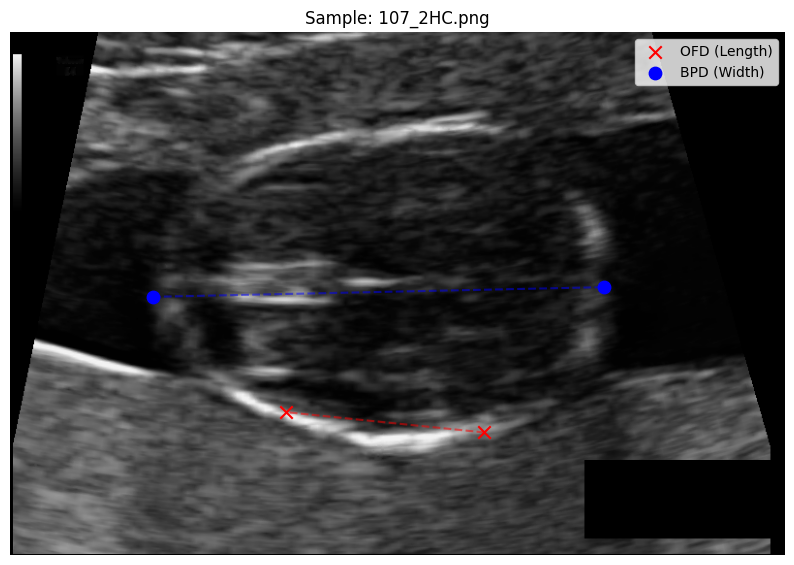

In [ ]:
row = df_landmark.iloc[130]
print(row)
image_path = row['image_path']

image = cv2.imread(image_path)

# Convert BGR (OpenCV default) to RGB (Matplotlib default)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get Coordinates (Using your specific column names)
# We will pair them up: (x, y)
# OFD Points
ofd_points = [
        (row['ofd_1_x'], row['ofd_1_y']),
        (row['ofd_2_x'], row['ofd_2_y'])
    ]

# BPD Points
bpd_points = [
        (row['bpd_1_x'], row['bpd_1_y']),
        (row['bpd_2_x'], row['bpd_2_y'])
    ]

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title(f"Sample: {row['image_name']}")

# Plot OFD points (Red)
for i, (x, y) in enumerate(ofd_points):
  plt.scatter(x, y, c='red', s=80, marker='x', label='OFD (Length)' if i==0 else "")

# Plot BPD points (Blue)
for i, (x, y) in enumerate(bpd_points):
  plt.scatter(x, y, c='blue', s=80, marker='o', label='BPD (Width)' if i==0 else "")

# Draw lines to connect them
plt.plot([p[0] for p in ofd_points], [p[1] for p in ofd_points], 'r--', alpha=0.5)
plt.plot([p[0] for p in bpd_points], [p[1] for p in bpd_points], 'b--', alpha=0.5)
plt.legend()
plt.axis('off')
plt.show()


There are some images and  coordinates that do not match properly.


### Now Let's create a function for resizing the images and coordinates and converting them into tensors.

In [ ]:
class LandmarkDataset(Dataset):
    def __init__(self, df, target_shape=(256, 256)):
        """
        df: The DataFrame from your Checkpoint
        target_shape: The size the Model needs (256x256)
        """
        self.df = df
        self.target_h, self.target_w = target_shape
        self.coord_cols = ['ofd_1_x', 'ofd_1_y', 'ofd_2_x', 'ofd_2_y',
                           'bpd_1_x', 'bpd_1_y', 'bpd_2_x', 'bpd_2_y']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load Original Image
        row = self.df.iloc[idx]
        img_path = row['image_path']
        image = cv2.imread(img_path)

        if image is None:
            return torch.zeros((3, self.target_h, self.target_w)), torch.zeros((4, self.target_h, self.target_w))

        # Get Original Dimensions
        orig_h, orig_w = image.shape[:2]

        # Get Raw Coordinates
        coords = row[self.coord_cols].values.astype(float).reshape(4, 2)

        # Calculate Scale Factor (Target Size / Original Size)
        scale_x = self.target_w / orig_w
        scale_y = self.target_h / orig_h

        # Resize Image
        image_resized = cv2.resize(image, (self.target_w, self.target_h))

        # Resize Coordinates (Apply Scale)
        coords[:, 0] *= scale_x
        coords[:, 1] *= scale_y

        # Generate Heatmaps (The Target for the AI)
        heatmaps = np.zeros((4, self.target_h, self.target_w), dtype=np.float32)
        for i in range(4):
            cx, cy = coords[i]
            # Create glowing dot at the resized coordinate
            heatmaps[i] = self.generate_gaussian(self.target_h, self.target_w, cx, cy, sigma=5)

        # Convert to Tensor (Normalize 0-1)
        image_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float() / 255.0
        heatmap_tensor = torch.from_numpy(heatmaps).float()

        return image_tensor, heatmap_tensor

    def generate_gaussian(self, height, width, cx, cy, sigma=5):
        """Helper to create the glowing white dot"""
        x = np.arange(0, width, 1, float)
        y = np.arange(0, height, 1, float)
        y = y[:, np.newaxis]
        return np.exp(-4*np.log(2) * ((x-cx)**2 + (y-cy)**2) / sigma**2)

### Let's verify if the code is working.

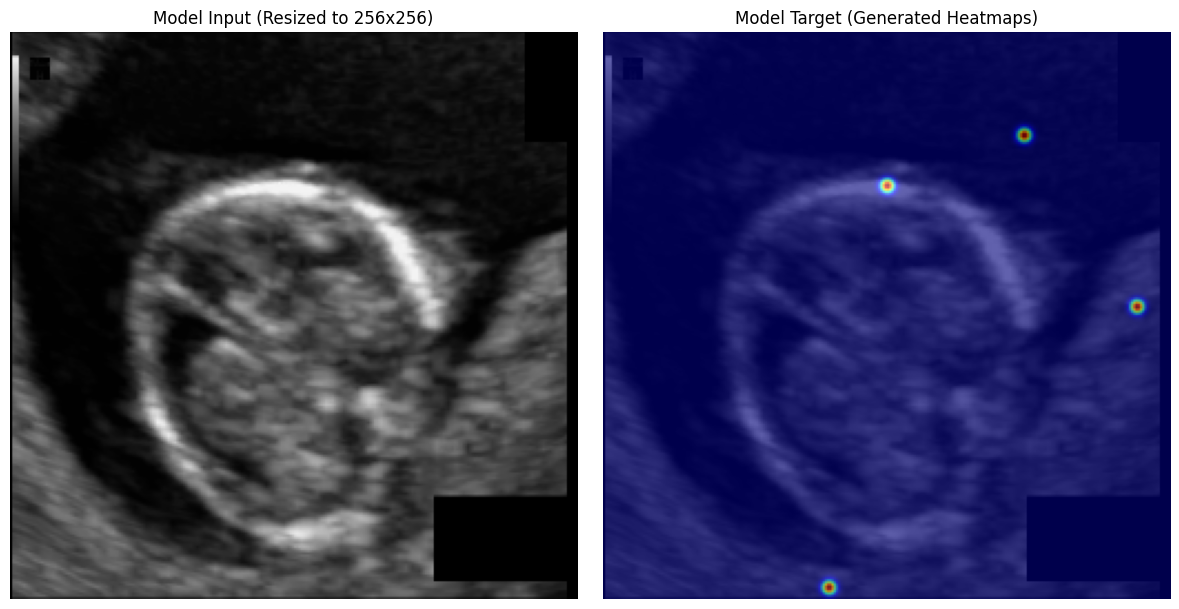

In [ ]:
idx=25
# Initialize the Dataset
# We use the 'df_landmark' from your Checkpoint step
train_ds = LandmarkDataset(df_landmark, target_shape=(256, 256))

# Get the SAME sample as before
image_tensor, heatmap_tensor = train_ds[idx]

# Prepare for Plotting
# Convert PyTorch Tensor (3, 256, 256) -> Numpy Image (256, 256, 3)
img_vis = image_tensor.permute(1, 2, 0).numpy()

# Squash the 4 heatmap channels into 1 image so we can see them all
heatmap_vis = torch.sum(heatmap_tensor, dim=0).numpy()

# Plot
plt.figure(figsize=(12, 6))

# Left: The Resized Image
plt.subplot(1, 2, 1)
plt.title(f"Model Input (Resized to {train_ds.target_w}x{train_ds.target_h})")
plt.imshow(img_vis)
plt.axis('off')

# Right: The Target Heatmaps (Overlaid)
plt.subplot(1, 2, 2)
plt.title("Model Target (Generated Heatmaps)")
plt.imshow(img_vis, cmap='gray') # Show image in background
plt.imshow(heatmap_vis, cmap='jet', alpha=0.6) # Overlay glowing dots
plt.axis('off')

plt.tight_layout()
plt.show()

### Splitting the Data

In [ ]:
# test_size=0.2 means 20% of images are saved for the validation
train_df, val_df = train_test_split(df_landmark, test_size=0.2, random_state=42)

### Modeling
Instead of making our own U-Net we will be using an already available one (Transfer learning).
best one i fell is Resnet.

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.4 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

# Load a U-Net with a ResNet34 backbone (Pre-trained on ImageNet)
model = smp.Unet(
    encoder_name="resnet34",        # The backbone (already knows how to see features)
    encoder_weights="imagenet",     # Use the pre-trained knowledge
    in_channels=3,                  # Input is RGB
    classes=4                       # Output is 4 Heatmaps
)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Loaded Pre-Trained ResNet34-UNet!")

Loaded Pre-Trained ResNet34-UNet!


### Now that we have everything set up Let's train the model.

In [ ]:
# CONFIGURATION
BATCH_SIZE = 8
LEARNING_RATE = 0.001
EPOCHS = 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create Datasets (Using the Letterbox Class you defined earlier)
train_ds = LandmarkDataset(train_df, target_shape=(256, 256))
val_ds = LandmarkDataset(val_df, target_shape=(256, 256))

# Create Loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training on {len(train_df)} images. Validating on {len(val_df)} images.")

# SETUP TRAINING
# Loss: Mean Squared Error (Standard for Heatmaps)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# TRAINING LOOP
print(f"Starting Training on {device}...")

for epoch in range(EPOCHS):
    model.train() # Set model to training mode
    running_loss = 0.0

    # Progress Bar
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, heatmaps in loop:
        # Move data to GPU
        images = images.to(device)
        heatmaps = heatmaps.to(device)

        # Forward Pass
        preds = model(images)
        loss = criterion(preds, heatmaps)

        # Backward Pass (The Learning Part)
        optimizer.zero_grad() # Clear old gradients
        loss.backward()       # Calculate new gradients
        optimizer.step()      # Update weights

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # End of Epoch Stats
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Done. Average Loss: {avg_loss:.6f}")

print("\nTraining Complete! You now have a working Model.")

Training on 497 images. Validating on 125 images.
Starting Training on cuda...


Epoch 1/15: 100%|██████████| 63/63 [07:31<00:00,  7.17s/it, loss=0.00416]


Epoch 1 Done. Average Loss: 0.055259


Epoch 2/15: 100%|██████████| 63/63 [00:16<00:00,  3.72it/s, loss=0.00206]


Epoch 2 Done. Average Loss: 0.000932


...

Epoch 13 Done. Average Loss: 0.000127


Epoch 14/15: 100%|██████████| 63/63 [00:16<00:00,  3.80it/s, loss=0.000508]


Epoch 14 Done. Average Loss: 0.000121


Epoch 15/15: 100%|██████████| 63/63 [00:16<00:00,  3.82it/s, loss=0.000489]

Epoch 15 Done. Average Loss: 0.000117

Training Complete! You now have a working Model.


### Let's do some predictions.


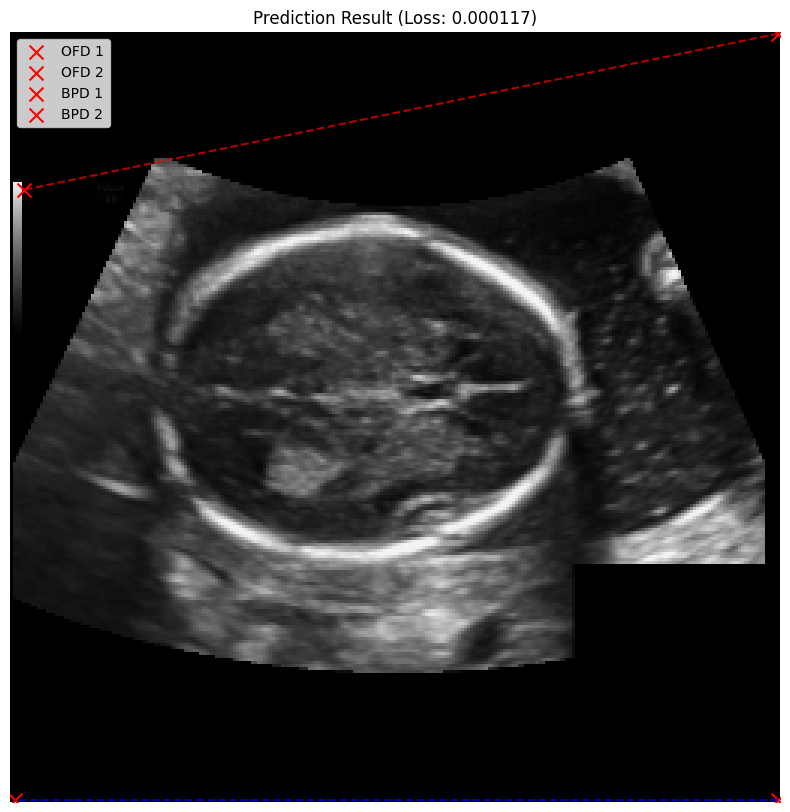

In [ ]:
val_image_tensor, val_target_heatmaps = val_ds[10]

input_tensor = val_image_tensor.unsqueeze(0).to(device)

# Predictions
model.eval() # Switch to evaluation mode
with torch.no_grad():
    output_heatmaps = model(input_tensor)

# Post-Processing: Convert Heatmaps back to (X, Y) coordinates
pred_heatmaps = output_heatmaps.squeeze(0).cpu().numpy() # Remove batch dim
pred_coords = []

for i in range(4):
    hm = pred_heatmaps[i]
    # Find the pixel with the highest value
    y, x = np.unravel_index(hm.argmax(), hm.shape)
    pred_coords.append((x, y))

# 5. Visualization
img_vis = val_image_tensor.permute(1, 2, 0).numpy() # Convert to standard image format

plt.figure(figsize=(10, 10))
plt.imshow(img_vis)
plt.title(f"Prediction Result (Loss: {0.000117})")

# Plot Predicted Points (Red X)
labels = ['OFD 1', 'OFD 2', 'BPD 1', 'BPD 2']
for i, (x, y) in enumerate(pred_coords):
    plt.scatter(x, y, c='red', s=100, marker='x', label=labels[i])

# Draw lines to see the cross shape
plt.plot([pred_coords[0][0], pred_coords[1][0]], [pred_coords[0][1], pred_coords[1][1]], 'r--', alpha=0.7)
plt.plot([pred_coords[2][0], pred_coords[3][0]], [pred_coords[2][1], pred_coords[3][1]], 'b--', alpha=0.7)

plt.legend()
plt.axis('off')
plt.show()

## I have tried mmany modifications and scaling to fix thee dataset. but the provided dataset seems to have inaccuracy in it for training and maybe that is why there is such a big error in the predictions even though the model shows very low loss value.

In [ ]:
save_path = "hypothesis_final_full_saved_model.pth"
torch.save(model.state_dict(), save_path)

print(f"Model saved as: {save_path}")
print("Check the 'Files' tab on the left to download it!")

Model saved as: hypothesis_final_full_saved_model.pth
Check the 'Files' tab on the left to download it!
